In [1]:
# preamble
import os
import sys
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes 
import pdb
import numpy as np
import os as os_module
from scipy.integrate import solve_ivp
from scipy.special import erfc, erf
import pandas as pd
from matplotlib import ticker
import scipy as sp
import seaborn as sns
from scipy.special import erf
from scipy.optimize import fsolve
from scipy.integrate import cumulative_trapezoid, trapezoid, odeint, solve_bvp, solve_ivp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import colormaps
import matplotlib.ticker as mtick
from matplotlib.ticker import EngFormatter, LogLocator, FuncFormatter, NullFormatter, FixedLocator, StrMethodFormatter, LogFormatter, LogFormatterSciNotation, LogFormatterExponent, LogFormatterMathtext, FixedFormatter
from matplotlib.lines import lineStyles
import cmocean
import cmocean.cm as cmo
from matplotlib.colors import LogNorm
from IPython.display import clear_output
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from labellines import labelLines
from itertools import cycle
from seafreeze import seafreeze as sf
def sci_fmt(x):
    if x == 0 or not np.isfinite(x):
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10**exp)
    # round mantissa to integer as you requested
    return rf"{mant:.0f}$×10^{{exp}}$"

In [2]:
# constants
beta = 4e-10 # Pa-1, compressibility at 273 K
rhow = 1025 # kg m-3
rhoi = 916 # kg m-3
delta_rho = rhow - rhoi # kg m-3
delta_rho_inv = rhoi - rhow
Cp = 4.2e3 # J kg-1 K
kappa = 1e-6 # thermal diffusivity (m2/s)
λ = 0.65 # thermodynamic parameter of ice (adimensional)
g = 1.315 # m/s2
nu = 0.3 # Poisson's ratio
E = 5e9 # Pa, Young's modulus of ice
G = 3.3e9 # Pa, shear modulus from Berne et al., 2023
m = G / (1 - nu)
eta_w = 1.3e-3 # Pa s, viscosity of water

# tensile strength
S = 1e6 # Pa, tensile strength of ice
Kc = 1e6 # Pa m1/2, fracture toughness of ice

# depth params OBSOLETE
ymi = 1 # m, initial ice shell thickness
R = 1.5608e6 # m, radius of Europa
rc = 1.4608e6 - 130 # m, radius to top of silicate component
rii = R - ymi # m, initial radius of ice shell base
ri_timed = np.zeros((1,2)) # m, radii of ice shell base
ri_timed[0,0] = 0
ri_timed[0] = [rii, 0]
dzi = (ymi)/61
dti = 0.1*((0.1*(dzi**2))/kappa)

## time params OBSOLETE
y2sec = 3.1536e7 # s/yr
tend = 5e6*y2sec # end time (s)
t = ((ymi/(2*λ))**2)/kappa # starting time (s)
n = 0 # first iteration


In [3]:
# effective T of water and brine
def Tm_eff(p):
    """
    calculate the effective melting temperature of water at a given pressure.
    p: pressure at which to calculate the melting temperature (Pa)
    p0: reference pressure (Pa)
    returns the effective melting temperature (K)
    """
    Tm0_salt = 252 # (K) melting for NaCl brines 0.1 and 0.6 M
    Tm0_fresh = 273.15 # (K) melting
    p0 = 1e5 # (Pa) reference pressure
    dTm_dP = -7.4e-8 # (K/Pa) P dependence of the melting curve
    Tm_eff = Tm0_salt + (dTm_dP) * (p - p0)
    return Tm_eff


In [4]:
# let the brines' mushy zone, after onset of freezing, be 21 K (273-252)
# calculating melt fraction φ

def melt_fraction(Tz, p,):
    """
    calculate the melt fraction φ based on temperature T, pressure p, and reference pressure p0.
    T: temperature (K)
    p: pressure (Pa)
    p0: reference pressure (Pa)
    returns the melt fraction φ (dimensionless)
    """
    x = Tz - Tm_eff(p)
    DPpc = 21 # (K) mushy zone width
    # phi = np.zeros_like(Tz) if isinstance(Tz, np.ndarray) else 0.0
    # mush = (Tz >= 251.73) & (Tz < 272.88)
    phi = 0.5 + 0.9375*(x/DPpc) - 0.625*(x/DPpc)**3 + 0.1875*(x/DPpc)**5
    phi = np.where(x <= -DPpc, 0.0, phi)
    phi = np.where(x >= DPpc, 1.0, phi)    
    return phi

In [5]:
# transient heat conduction equation, from Luju's Europaquakes
def c_eff(Tz, p):
    """
    L = latent heat of fusion (J/kg)
    c = specific heat capacity (J/kg/K)
    dmeltfracdT = derivative of melt fraction with respect to temperature (1/K)
    c_eff = effective specific heat capacity (J/kg/K)
    Tz: vertical temperature profile (K)
    p: pressure (Pa)
    returns the effective specific heat capacity c_eff (J/kg/K)
    """
    c_liquid = 4.18e3 # (J/kg/K) specific heat capacity of liquid water
    c_solid = 1.5e3 # (J/kg/K) specific heat capacity of ice (approximately average based on SeaFreeze web-app (110-273 K, 1-100 MPa))
    c_modular = melt_fraction(Tz,p)*c_liquid + (1 - melt_fraction(Tz,p))*c_solid # weighted average of c_p
    L_fus = 334e3 # (J/kg) latent heat of fusion for water
    # dmeltfracdT = np.gradient(melt_fraction(Tz,p), Tz) # (1/K) derivative of melt fraction with respect to temperature
    dmeltfracdT = np.zeros_like(Tz)
    mushy_mask = (Tz >= 251.73) & (Tz < 272.88)
    dmeltfracdT[mushy_mask] = 1.0 / (272.88 - 251.73)
    c_eff_of_T = c_modular + L_fus * (dmeltfracdT)
    return c_eff_of_T

def tempgrad(Tz, p, N, h_tot):
    """
    Ts: surface temperature (K)
    Tb: basal temperature (K)
    h_tot: total ice shell thickness (m)
    z: depth array (m)
    Tz: temperature profile (K)
    k: thermal conductivity ice, non-porous (W/m/K)
    dTdt: derivative of temperature with respect to time (K/s)
    """
    Ts = 110
    Tb = 260
    # h_tot = 5e3
    z = np.linspace(0, h_tot, N)
    Tz = Ts + (Tb - Ts) / h_tot * z
    Tz[(z >= d - a) & (z <= d + a)] = 2740
    ki = 567.0 / np.maximum(Tz, 1)
    kl = 0.6
    rho_modular = melt_fraction(Tz, p) * rhow + (1 - melt_fraction(Tz, p)) * rhoi
    k_modular = melt_fraction(Tz, p) * kl + (1 - melt_fraction(Tz, p)) * ki
    dTdz = np.gradient(Tz, z)
    dTdt = np.gradient(k_modular * dTdz, z) / (c_eff(Tz, p) * rho_modular)
    return dTdt

In [6]:
def P_critical(d, Dmech):
    """
    d: depth (m)
    returns the critical overpressure (Pa)
    """
    m = 2 # damage strength exponent
    sigma_T = 0.7e6 + (3.1e6 - 0.7e6) * (1 - Dmech)**m # (Pa) tensile strength profile from Luju's 2026 Europaquakes ()
    # sigma_T[9]/1e6
    DPc = 2 * (sigma_T + rhoi * g * d) # (Pa) critical overpressure for dike propagation, eqn 4 of Lesage et al. (2022)
    return DPc

In [7]:
def mass_conservation_rate(rho, V, drho_dP, drho_dT, dP_dt, dT_dt, dV_dt):
    """
    Calculates d(rho*V)/dt for your coupled system, Sir.
    """
    # Time derivative of density via the chain rule
    drho_dt = drho_dP * dP_dt + drho_dT * dT_dt
    
    # Rate of change of total mass via the product rule
    dM_dt = rho * dV_dt + V * drho_dt
    return dM_dt

def mass_conservation_residual(M_in, M_out, dMass_dt):
    """
    Returns the residual: (M_in - M_out) - d(rho*V)/dt.
    """
    return (M_in - M_out) - dMass_dt

In [8]:
# Luju's Europaquakes paper uses a rectangular sill of height 100-500 m and width of 1 km
A_rectangular_sill = 1e3 * 100
# For a spherical sill of radius 500 m
A_spherical_sill_500 = 4 * np.pi * (5e2)**2
A_spherical_sill_1000 = 4 * np.pi * (1e3)**2
A_spherical_sill_100 = 4 * np.pi * (1e2)**2
print(f"Rectangular sill area: {A_rectangular_sill:.0e} m^2")
print(f"Spherical sill area: {A_spherical_sill_500:.0e} m^2")
print(f"The spherical sill's area is {A_spherical_sill_500/A_rectangular_sill:.2f} times larger than that of the rectangular sill.")
print(f"The spherical sill's area is {A_spherical_sill_1000/A_rectangular_sill:.2f} times larger than that of the rectangular sill.")
print(f"But, the spherical sill's area is only {A_spherical_sill_100/A_rectangular_sill:.2f} times bigger than that of the rectangular sill.")

Rectangular sill area: 1e+05 m^2
Spherical sill area: 3e+06 m^2
The spherical sill's area is 31.42 times larger than that of the rectangular sill.
The spherical sill's area is 125.66 times larger than that of the rectangular sill.
But, the spherical sill's area is only 1.26 times bigger than that of the rectangular sill.


In [9]:
# Surface uplift resulting from chamber inflation (freezing) from Townsend (2022) w/ pressures from Chivers et al. (2020) and Amoruso and Crescentini (2009)
# Σ^n_(k=1)... k spans from 1 to n

N = 1001
N_t = 1001
year = 3.15e7 # seconds in a year
t = np.linspace(1, 5e4, N_t)*year # (s), Chivers et al. (2020) results for a liquid water chamber 1-3 km depth
dt = np.diff(t, prepend=0) # (s) time step
β = 4.9e-10 # (Pa-1) compressibility of water
# DP = 1e6 # (Pa) 
mu = G # shear modulus (Pa)

##### EDITABLE #####
a = 1e3 # (m) radius of chamber (assumption of sphericity) 
S = a + 5e2 # (m) static chamber + shell thickness
r = np.linspace(a, S, N) # (m) radial distance from chamber edge
d = 3e3 # (m) depth of chamber below surface (note tha a is radius, so 2a is the minimum depth)
##### EDITABLE #####

rhoi_Lesage = 1130 # (kg/m3) ice density from Lesage et al. (2022)
L_fus = 334e3 # (J/kg) latent heat of fusion for water
Q = 6e4 # (J/mol) ice activation energy from Chivers et al. (2021)
eta_ref = 1e13 # (Pa s) reference viscosity from Chivers et al. (2021)
Rg = 8.314 # (J/mol/K) gas constant

########
# (Pa) pressure in the chamber, Amoruso and Crescentini (2009) via Chivers et al. (2020)
Plith = rhoi_Lesage*g*(d-a) # (d-a) = depth of chamber roof
T_chamber_history = np.zeros(N_t) # (K) temperature in the chamber, Chivers et al. (2020)
DP = np.zeros(N_t)
h_tot = 5e3 # brittle shell thickness
z = np.linspace(0, h_tot, N)
# idx = int(np.argmin(np.abs(z-d)))
Tm = 251
Tc = 170
Ts = 110
Tb = 250
# Tz = Ts * (Tb/Ts)**(z/h_tot) # equilibrium profile (Chivers et al., 2021)
Tz = Ts + z * (Tb - Ts) / h_tot # linear profile
Tz[(z >= d - a) & (z <= d + a)] = 274 # chamber T bounds; Boolean indexing to set the temperature at the margins of the chamber
ki = 567 / Tz
κ = ki / (rhoi * Cp)
# Tz = np.clip(Tz, 1.0, 300.0)
phis = np.zeros(N_t) # 
phis[0] = 1 # initial melt fraction, 100% liquid
T_chamber = np.interp(d, z, Tz)
T_chamber_history[0] = T_chamber # initial temperature in the chamber, Chivers et al. (2020)

K = E / (3 * (1-2*nu)) # bulk modulus (Pa)
eta_0 = 1e14 # (Pa s) Barr and Showman (2009) ice viscosity
tR = np.zeros(N_t) # (s) relaxation timescale
tR[0] = 1e20
etas = [] # (Pa s) shell viscosity
rhs = (Tm - Tc) * c_eff(Tz, Plith) / (L_fus * np.sqrt(np.pi))
# Solve the transcendental equation for lambda (thermal transfer rate)
def stefan(kappa, t, rhs):
    lam = 0.53 ##### EDITABLE #####
    Tz = Tc + (Tm - Tc)/(1 + erf(lam)) * (1 + erf(z/(2*np.sqrt(kappa*t))))
    return Tz

V = 4/3 * np.pi * a**3 # total volume prior to freezing
Ve = 0 # expelled volume prior to freezing
Dmech = 0 # scalar mechanical damage coefficient (Europaquakes (42-45))
A_damage = np.linspace(0.2, 0.01, N_t) # initial mechanical damage fraction
dt_step = t[1] - t[0]
hyst = 0.02 # hysteresis factor
crack = False

In [10]:
for n in range(1, N_t):
    Tz = stefan(κ, t[n], rhs) # T(z,t): thermal profile for 
    # T_chamber_history[n] = Tz[idx]
    T_chamber = np.interp(d, z, Tz) 
    T_chamber_history[n] = T_chamber
    T = Tc + (T_chamber_history[n] - Tc) * (a / r)
    ki = 567 / T_chamber
    κ = ki / (rhoi * Cp)
    # λ = S / (2*np.sqrt(κ*t))
    P_abs = Plith + DP[n-1]
    Tz = Tz + tempgrad(Tz, P_abs, N, h_tot) * dt_step
    phi_prev = phis[n-1]
    # phi_now = float(melt_fraction(T_chamber, P_abs))
    Sc = 2 * 0.53 * np.sqrt(κ*t[n]) # (m) frozen layer thickness (Lesage et al., 2022)
    phi_now = (1 - Sc/a)**3 # melt fraction from Lesage (2022) eqn 2
    dphi = phi_prev - phi_now
    dP_freezing = dphi * (rhow/rhoi - 1) / (((1 - 2*nu)/E * (2*a/d * 4/np.pi * ((1 - nu**2)/(1 - 2*nu) - 3)) + beta)) 
    # max tensile stress from freezing (B3 from Manga and Michaut, 2017)? 
    dP_new = max(0, DP[n-1] + dP_freezing)
    dDevent = A_damage[n] * (1-Dmech) 
    Dmech = min(1, Dmech + dDevent)
    P_open = P_critical(d, Dmech)*(1 + hyst)
    P_close = P_critical(d, Dmech)*(1 - hyst)
    crack = dP_new >= P_open
    DP[n] = 0 if crack else dP_new
    phis[n] = phi_now
    dt_step = t[n] - t[n-1]
    dP_dt = dP_freezing/dt_step if crack else (DP[n] - DP[n-1]) / dt_step 
    dT_dt = (T_chamber_history[n] - T_chamber_history[n-1]) / dt_step
    dV_dt = 0
    dV = dV_dt * dt_step
    Vn = V # updates current volume Vn to be equal to total V(n-1) minus ejected V(n-1)
    rho_mix = phis[n] * rhow + (1-phis[n]) * rhoi
    drho_dP = beta * rho_mix
    drho_dT = (rhow - rhoi) * ((phis[n] - phis[n-1]) / (T_chamber_history[n] - T_chamber_history[n-1] + 1e-15))
    dM_dt = mass_conservation_rate(rho_mix, V, drho_dP, drho_dT, dP_dt, dT_dt, dV_dt)
    Ve = Vn * phis[n] * (rhow/rhoi) if crack else 0 # coming from Lesage et al. (2022) (6)--if cracking occurs, mass is ejected
    V = Vn - Ve
    M_out = rhow * Ve # expelled mass from diking, if Ve=0 ==> M_out=0
    M_in = 0 # no influx
    residual = mass_conservation_residual(M_in, M_out, dM_dt)
    # eta_S = eta_0 * np.exp(26.4 * ((273.15 / T) - 1)) # (Pa s) Arhennius relationship from Manga and Michaut (2017)
    eta_S = eta_ref * np.exp((Q / (Rg*Tm)) * (Tm/T - 1)) # (Pa s) Arhennius relationship from Chivers et al. (2021)
    etas.append(eta_S)
    eta_eff = 3 * a**3 * np.trapz(eta_S / (r**4), r) # (Pa s) effective viscosity of shell
    tau = eta_eff/mu
    tau_a = tau*(3*K+mu)/(3*K)
    tR[n] = (3 * eta_eff * (1 - nu) / (mu * (1 + nu)) * (S/a)**3)
    dP = np.diff(DP, prepend=0)
    if np.isnan(T_chamber) or np.isnan(DP[n]) or np.isnan(phis[n]) or np.isnan(tR[n]):
        print(f"NaN at time step {n}. Stopping simulation.")
        break
    checks = {
        "T_chamber <= 0": T_chamber <= 0,
        "phi <= 0": phis[n] <= 0,
        "tR <= 0": tR[n] <= 0,
    }
    if any(checks.values()):
        print(f"Zero at time step {n}.")
        # print(f"Conditions: {checks}")
        print(f"T_chamber = {T_chamber:.2f} K")
        print(f"DP = {DP[n]:.2g} Pa")
        print(f"phi = {(phis[n]*100):.2f}%")
        print(f"tR = {tR[n]:.2e} s")
        print(f"P_critical = {P_critical(d,Dmech)/1e6:.2g} MPa")
        break
    if n % 100 == 0 or n % 50 == 0:
        print(f"Time step {n}: t = {t[n]/year/1e3:.2g} ka, T_chamber = {T_chamber:.2f} K, ΔP = {DP[n]/1e6:.2f} MPa, φ = {phis[n]*100:.2g}%")
    # t_n: (s) current time 
########

uz = np.zeros(N_t) # (m) surface uplift

for n in range(0, N_t):
    uzn = 0
    for k in range(0, n+1):
        # equation 12--viscoelastic shell
        tR = np.maximum(tR, 1e-12)
        uz_k = (1-nu)*dP[k]*a**3 / (mu*d**2) * (np.exp(-((t[n]-t[k])/tR[k])) + (S/a)**3 * (1-np.exp(-((t[n]-t[k]) / tR[k]))))
        uzn += uz_k
    uz[n] = uzn
    # uz_slice = uz[N-1]

Time step 50: t = 2.5 ka, T_chamber = 274.76 K, ΔP = 4.17 MPa, φ = 48%
Time step 100: t = 5 ka, T_chamber = 274.76 K, ΔP = 6.24 MPa, φ = 33%
Time step 150: t = 7.5 ka, T_chamber = 274.76 K, ΔP = 0.50 MPa, φ = 24%
Time step 200: t = 10 ka, T_chamber = 274.76 K, ΔP = 3.65 MPa, φ = 18%
Time step 250: t = 13 ka, T_chamber = 274.75 K, ΔP = 0.79 MPa, φ = 13%
Time step 300: t = 15 ka, T_chamber = 274.75 K, ΔP = 3.29 MPa, φ = 10%
Time step 350: t = 18 ka, T_chamber = 274.75 K, ΔP = 3.01 MPa, φ = 7.6%
Time step 400: t = 20 ka, T_chamber = 274.74 K, ΔP = 0.70 MPa, φ = 5.7%
Time step 450: t = 23 ka, T_chamber = 274.72 K, ΔP = 5.78 MPa, φ = 4.2%
Time step 500: t = 25 ka, T_chamber = 274.70 K, ΔP = 0.84 MPa, φ = 3%
Time step 550: t = 28 ka, T_chamber = 274.66 K, ΔP = 3.81 MPa, φ = 2.1%
Time step 600: t = 30 ka, T_chamber = 274.60 K, ΔP = 6.05 MPa, φ = 1.5%
Time step 650: t = 33 ka, T_chamber = 274.53 K, ΔP = 7.71 MPa, φ = 0.98%
Time step 700: t = 35 ka, T_chamber = 274.45 K, ΔP = 0.10 MPa, φ = 0.63

(0.0, 50.0)

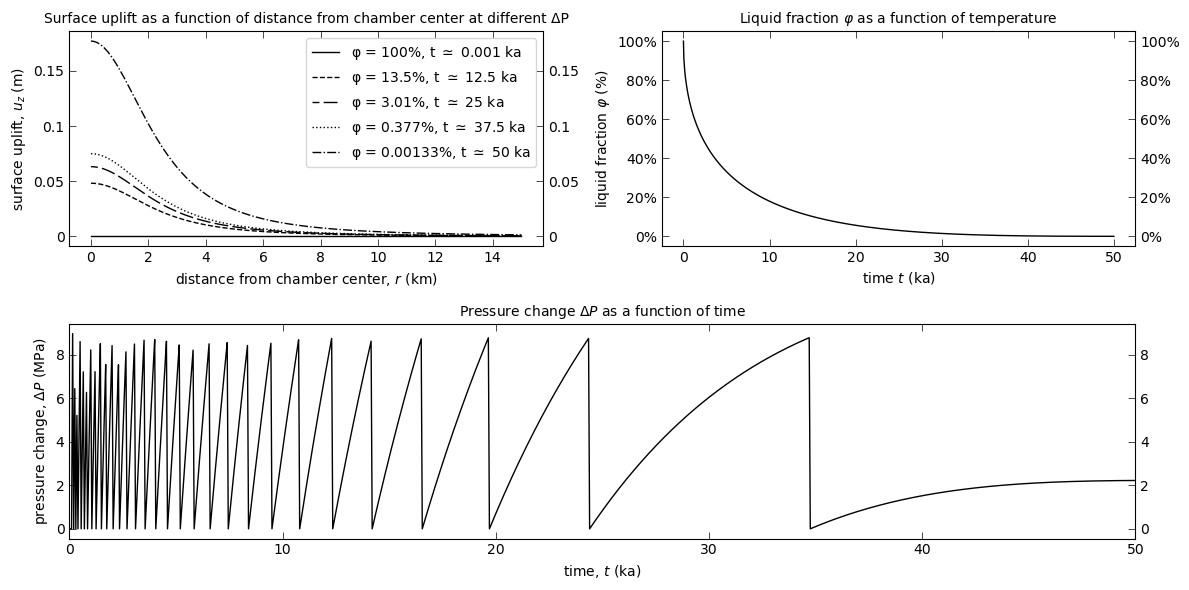

In [11]:
lines = ['-', '--', (5, (10, 3)), ':', '-.']
coolcolor = '#1f77b4'
lw = 1
fig = plt.figure(figsize=(12, 6), layout='tight')
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=3)

surface = np.linspace(0, 15e3, N) # (m) distance from chamber center
# Should we initiate with pit conditions? Is surface depressed from downward flexure?

for i, j in enumerate(np.linspace(0, N-1, 5, dtype=int)):
    uz_slice = uz[j]  # Center uplift at this specific freezing step
    uz_plot = uz_slice * (d**2 / (d**2 + surface**2))**1.5  # Project spatially
    ax1.plot(surface/1e3, uz_plot, lw=lw, label=f'φ = {phis[j]*100:.3g}%, t $\simeq$ {(t[j]/year)/1e3:.3g} ka', ls=lines[i], color='black')
ax1.set_xlabel('distance from chamber center, $r$ (km)', fontsize=10)
ax1.set_ylabel('surface uplift, $u_z$ (m)', fontsize=10)
ax1.tick_params(which='major', length=5, width=0.5, direction='in', top=True, right=True, labelright=True)
ax1.tick_params(which='minor', length=3, width=0.5, direction='in', top=True, right=True)
ax1.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax1.set_title('Surface uplift as a function of distance from chamber center at different ΔP', fontsize=10)
ax1.legend(loc='upper right', fontsize=10)
# ax1.set_xlim(0, 15)

ax2.plot(t/year/1e3, phis*100, lw=lw, color='black')
ax2.set_ylabel('liquid fraction $φ$ (%)', fontsize=10)
ax2.set_xlabel('time $t$ (ka)', fontsize=10)
ax2.tick_params(which='major', length=5, width=0.5, direction='in', top=True, right=True, labelright=True)
ax2.tick_params(which='minor', length=3, width=0.5, direction='in', top=True, right=True)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax2.set_title('Liquid fraction $φ$ as a function of temperature', fontsize=10)
# ax2.invert_xaxis()
# ax2.set_xlim(274, 230.82)

ax3.plot((t/year)/1e3, DP/1e6, lw=lw, color='black')
ax3.set_ylabel('pressure change, $ΔP$ (MPa)', fontsize=10)
ax3.set_xlabel('time, $t$ (ka)', fontsize=10)
ax3.tick_params(which='major', length=5, width=0.5, direction='in', top=True, right=True, labelright=True)
ax3.tick_params(which='minor', length=3, width=0.5, direction='in', top=True, right=True)
ax3.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax3.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax3.set_title('Pressure change $ΔP$ as a function of time', fontsize=10)   
ax3.set_xlim(0, 50)


######## Toothed φ indicative of rapid refreezing resulting from instantaneous pressure drop after fracture?

/var/folders/4y/tw1pwdb527z5vwkr7_zjbgvw0000gn/T/ipykernel_59535/3191924607.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot2grid((1, 2), (0, 0))


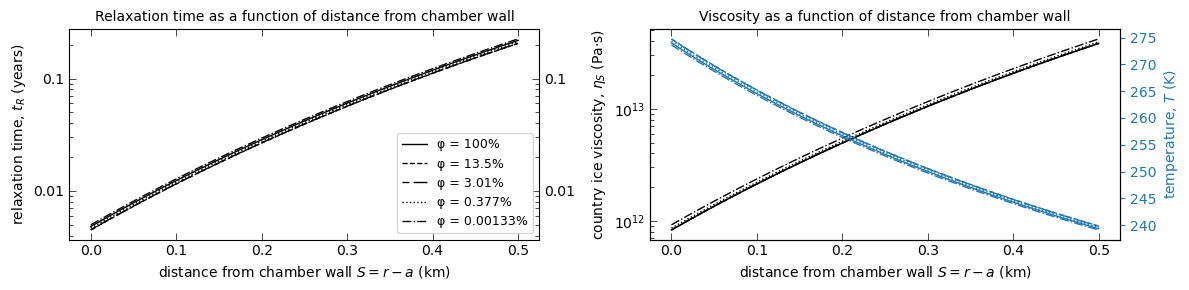

In [12]:
fig, ax = plt.subplots(figsize=(12, 3), layout='tight')
ax1 = plt.subplot2grid((1, 2), (0, 0))
ax2 = plt.subplot2grid((1, 2), (0, 1))

from_wall = (r-a)/1e3 # (m) distance from chamber wall
T_r_array = []
for i, j in enumerate(np.linspace(0, N_t-1, 5, dtype=int)):
    T_chamber = T_chamber_history[j]
    T_r = Tc + (T_chamber - Tc) * (a / r) # 1-D radial heat conduction sol. from Townsend (2022)
    T_r_array.append(T_r)
    eta_r = eta_0 * np.exp(26.4 * ((273.15 / T_r) - 1.0))
    tR_r = (3 * eta_r * (1 - nu)/(mu * (1 + nu)) * (S / a) ** 3)
    ax1.semilogy(from_wall, tR_r/year, lw=lw, ls=lines[i], color="black", label=f"φ = {phis[j]*100:.3g}%",)
ax1.set_xlabel("distance from chamber wall $S=r-a$ (km)", fontsize=10)
ax1.set_ylabel("relaxation time, $t_R$ (years)", fontsize=10)
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax1.set_title("Relaxation time as a function of distance from chamber wall", fontsize=10)
ax1.legend(loc="lower right", fontsize=9)
ax1.tick_params(which='major', length=5, width=0.5, direction='in', top=True, right=True, labelright=True)
ax1.tick_params(which='minor', length=3, width=0.5, direction='in', top=True, right=True)
# ax4.set_xlim(0, 0.5)
T_r_array = np.array(T_r_array)

for i, j in enumerate(np.linspace(0, len(etas)-1, 5, dtype=int)):
    ax2.semilogy(from_wall, etas[j], lw=lw, color="black", label=f"φ = {phis[j]*100:.3g}%", ls=lines[i])
ax2twin = ax2.twinx()
for i in range(0, 5):
    idx = np.linspace(0, len(T_r_array)-1, 5, dtype=int)
    ax2twin.plot(from_wall, T_r_array[idx[i]], lw=lw, color=coolcolor, ls=lines[i])
ax2.set_xlabel("distance from chamber wall $S=r-a$ (km)", fontsize=10)
ax2.set_ylabel("country ice viscosity, $η_S$ (Pa·s)", fontsize=10)
ax2.set_title("Viscosity as a function of distance from chamber wall", fontsize=10)
ax2.tick_params(which='major', length=5, width=0.5, direction='in', top=True)
ax2.tick_params(which='minor', length=3, width=0.5, direction='in', top=True)
ax2.yaxis.set_major_formatter(LogFormatterSciNotation())
ax2twin.set_ylabel("temperature, $T$ (K)", fontsize=10, color=coolcolor)
ax2twin.tick_params(axis='y', colors=coolcolor)
ax2twin.yaxis.set_major_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
# ax5twin.yaxis.set_major_formatter(LogFormatterSciNotation())
# ax5.legend(loc="lower right", fontsize=9)
# ax5.set_xlim(0, 0.5)